# Competition 1: Beer Quality Prediction 🍺

This notebook provides starter code for the Beer Quality Prediction competition. For full instructions, problem statement, and grading criteria, please refer to the **README.md** file.

**Quick Summary**: You will build a classification model to predict beer quality (scores 1-10) based on chemical properties. Submit your predictions to [Kaggle](https://www.kaggle.com/competitions/ift-6390-ift-3395-beer-quality-prediction/).

## Import Dependencies

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Load and Explore Data

In [3]:
# Load the training data
train_df = pd.read_csv('data/train.csv', delimiter=';', index_col="id")

# Training Data 
print(f"Training data shape: {train_df.shape}")
print(f"Number of samples (n): {train_df.shape[0]}")
print(f"Number of features (d): {train_df.shape[1] - 1}")  # Subtract 1 for target column
print(f"Columns: {list(train_df.columns)}")
print("\nFirst few rows:")
print(train_df.head())


Training data shape: (4469, 14)
Number of samples (n): 4469
Number of features (d): 13
Columns: ['beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength', 'quality']

First few rows:
   beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
id                                                                   
0        Pale           7.997                   0.446        0.280   
1        Pale           6.906                   0.222        0.303   
2       Brown           7.183                   0.636        0.071   
3        Pale           6.403                   0.242        0.260   
4       Brown           7.917                   0.182        0.347   

    final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity  \
id                                                                        
0          10.803   

In [4]:
# Check data types and basic info
print("\nData types and info for train df:")
print(train_df.info())


Data types and info for train df:
<class 'pandas.core.frame.DataFrame'>
Index: 4469 entries, 0 to 4468
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   beer_style              4469 non-null   object 
 1   bitterness_IBU          4469 non-null   float64
 2   diacetyl_concentration  4469 non-null   float64
 3   lactic_acid             4469 non-null   float64
 4   final_gravity           4469 non-null   float64
 5   sodium                  4469 non-null   float64
 6   free_CO2                4469 non-null   float64
 7   dissolved_oxygen        4469 non-null   float64
 8   original_gravity        4469 non-null   float64
 9   pH                      4469 non-null   float64
 10  gypsum_level            4469 non-null   float64
 11  alcohol_ABV             4469 non-null   float64
 12  fermentation_strength   4469 non-null   float64
 13  quality                 4469 non-null   int64  
dtypes: float64

In [5]:
test_df = pd.read_csv('data/test.csv', delimiter=';', index_col="id")

# Test Data 
print(f"Test data shape: {test_df.shape}")
print(f"Number of samples (n): {test_df.shape[0]}")
print(f"Columns: {list(test_df.columns)}")
print("\nFirst few rows:")
print(test_df.head())

Test data shape: (511, 13)
Number of samples (n): 511
Columns: ['beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength']

First few rows:
   beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
id                                                                   
0      Golden           7.904                   0.419        0.501   
1        Pale           6.317                   0.223        0.575   
2      Golden           5.483                   0.347        0.254   
3        Pale           5.183                   0.515        0.166   
4        Dark          13.505                   0.527        0.792   

    final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity  \
id                                                                        
0           8.200   0.074    31.994           163.998           

In [6]:
# Check data types and basic info
print("\nData types and info for test df:")
print(test_df.info())


Data types and info for test df:
<class 'pandas.core.frame.DataFrame'>
Index: 511 entries, 0 to 510
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   beer_style              511 non-null    object 
 1   bitterness_IBU          511 non-null    float64
 2   diacetyl_concentration  511 non-null    float64
 3   lactic_acid             511 non-null    float64
 4   final_gravity           511 non-null    float64
 5   sodium                  511 non-null    float64
 6   free_CO2                511 non-null    float64
 7   dissolved_oxygen        511 non-null    float64
 8   original_gravity        511 non-null    float64
 9   pH                      511 non-null    float64
 10  gypsum_level            511 non-null    float64
 11  alcohol_ABV             511 non-null    float64
 12  fermentation_strength   511 non-null    float64
dtypes: float64(12), object(1)
memory usage: 55.9+ KB
None


In [7]:
## Data Exploration and Visualization Continued 
# Listing column names for train and test data 

# Printing summary statistics 
print("\n Summary Statistics")
display(train_df.describe())

# Data Type per feature 
print("\n Data Type per feature")
print(train_df.dtypes.value_counts)



 Summary Statistics


,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
count,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000
mean,7.235609,0.338640,0.317996,5.506593,0.055572,30.744267,116.383056,0.994855,3.217238,0.528450,4.986386,9.478692,5.811815
std,1.296424,0.163701,0.145221,4.741626,0.033916,18.011711,56.441889,0.010509,0.161431,0.143315,0.560061,0.892119,0.838949
min,3.804000,0.064000,-0.022000,0.596000,-0.004000,0.998000,5.991000,0.957000,2.723000,0.216000,3.816000,7.429000,3.000000
25%,6.410000,0.226000,0.245000,1.805000,0.037000,16.999000,78.994000,0.988000,3.107000,0.430000,4.524000,8.778000,5.000000
50%,6.996000,0.293000,0.308000,3.119000,0.049000,29.001000,118.997000,0.995000,3.205000,0.506000,4.904000,9.348000,6.000000
75%,7.697000,0.404000,0.393000,8.196000,0.067000,41.984000,156.000000,1.002000,3.320000,0.598000,5.382000,10.109000,6.000000
max,15.885000,1.572000,1.672000,31.612000,0.603000,288.995000,440.004000,1.032000,4.006000,1.989000,7.096000,12.648000,9.000000



 Data Type per feature
<bound method IndexOpsMixin.value_counts of beer_style                 object
bitterness_IBU            float64
diacetyl_concentration    float64
lactic_acid               float64
final_gravity             float64
sodium                    float64
free_CO2                  float64
dissolved_oxygen          float64
original_gravity          float64
pH                        float64
gypsum_level              float64
alcohol_ABV               float64
fermentation_strength     float64
quality                     int64
dtype: object>


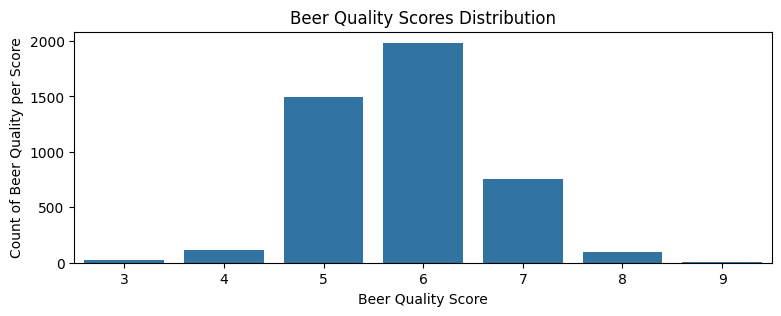

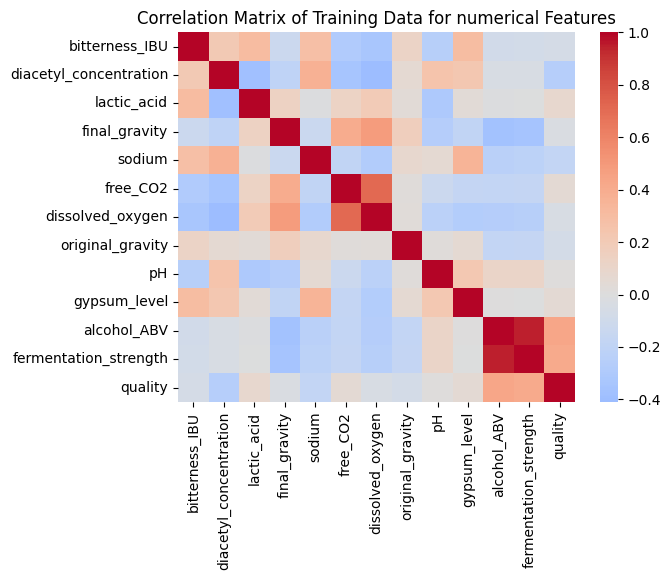

In [8]:
## Data Visualization and Exploring
## Visualizing Target variables
plt.figure(figsize=(9,3))
sns.countplot(x="quality",data=train_df)
plt.title("Beer Quality Scores Distribution")
plt.xlabel("Beer Quality Score")
plt.ylabel("Count of Beer Quality per Score")
plt.show()

## Plotting Correlation Matrix for numerical Features 
features = train_df.select_dtypes(include=["float64", "int64"]).columns
sns.heatmap(train_df[features].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Training Data for numerical Features")
plt.show()

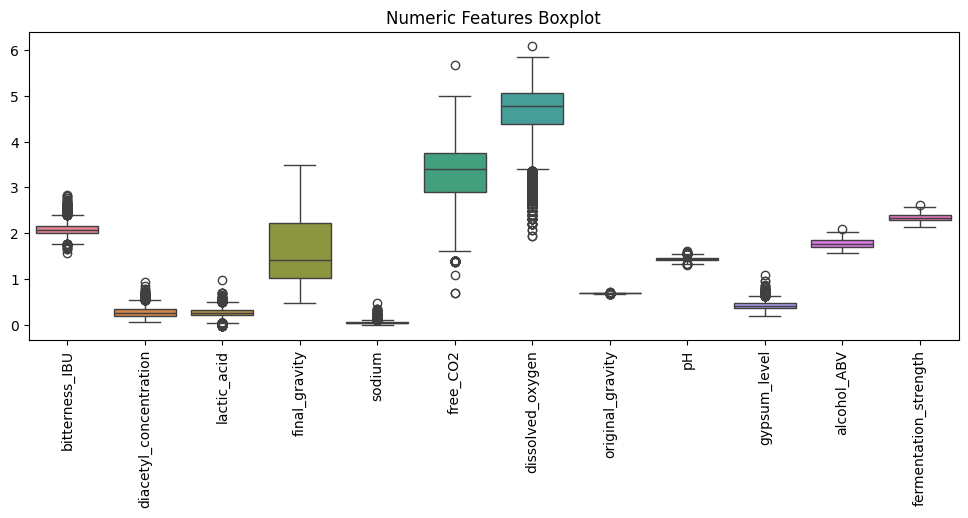

In [9]:
## Detecting Outliers for feature columns 
plt.figure(figsize=(12,4))
sns.boxplot(data=np.log1p(train_df[features.drop(["quality"], errors='ignore')]))
plt.xticks(rotation=90)
plt.title("Numeric Features Boxplot")
plt.show()

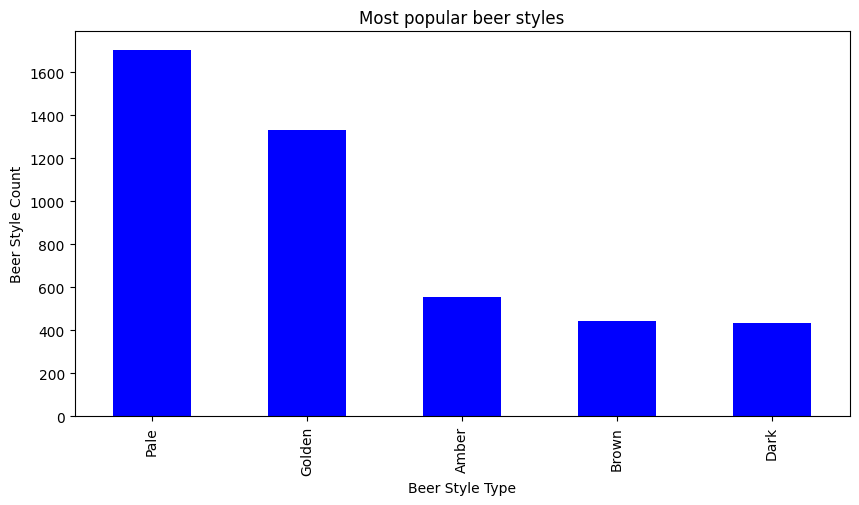

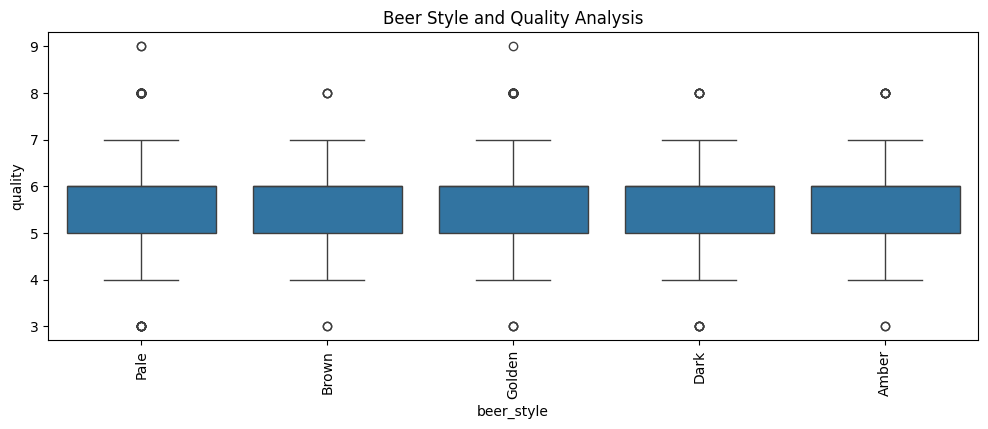

In [10]:
## Analyzing Categorial feature - Beer Style column 
plt.figure(figsize=(10,5))
train_df["beer_style"].value_counts().head().plot(kind="bar", color="blue")
plt.title("Most popular beer styles")
plt.xlabel("Beer Style Type")
plt.ylabel("Beer Style Count")
plt.show()

## Analyzing Beer Stlye relationship with Target 
plt.figure(figsize=(12,4))
sns.boxplot(x="beer_style", y="quality", data=train_df)
plt.xticks(rotation=90)
plt.title("Beer Style and Quality Analysis")
plt.show()

## Data Preprocessing

Implement your preprocessing pipeline (see README.md for suggestions).

In [11]:
# First copy the data frames to avoid modifying the original data frames
df_train = train_df.copy()
df_test = test_df.copy()

# Investigate missing values
print("Investigating the missing values before imputation.")
print(train_df.isnull().sum().sort_values(ascending=False))

# Fill numeric columns
# Identify numeric columns (exclude 'quality' if present)
numeric_cols = [col for col in df_train.select_dtypes(include=["float64", "int64"]).columns if col != "quality"]

for col in numeric_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())
    df_test[col] = df_test[col].fillna(df_train[col].median())

# Fill categorical column
df_train["beer_style"] = df_train["beer_style"].fillna(df_train["beer_style"].mode()[0])
df_test["beer_style"] = df_test["beer_style"].fillna(df_train["beer_style"].mode()[0])

# Print results
print("\n Missing values after imputations for Training data:")
print(df_train.isnull().sum().sum())

print("\n Missing values after imputations for Testing data:")
print(df_test.isnull().sum().sum())











Investigating the missing values before imputation.
beer_style                0
bitterness_IBU            0
diacetyl_concentration    0
lactic_acid               0
final_gravity             0
sodium                    0
free_CO2                  0
dissolved_oxygen          0
original_gravity          0
pH                        0
gypsum_level              0
alcohol_ABV               0
fermentation_strength     0
quality                   0
dtype: int64

 Missing values after imputations for Training data:
0

 Missing values after imputations for Testing data:
0


In [12]:
## Removing outlying data based on summary statistics results 
# Outlier clipping per feature distribution
for col in numeric_cols:
    if col in ['free_CO2', 'dissolved_oxygen', 'final_gravity']:
        lower, upper = np.percentile(df_train[col], [5, 95])
    elif col in ['alcohol_ABV', 'fermentation_strength']:
        lower, upper = np.percentile(df_train[col], [1, 99])
    else:
        lower, upper = np.percentile(df_train[col], [2, 98])
    df_train[col] = np.clip(df_train[col], lower, upper)


In [13]:
## Correlation:
## Printing the Top Correlated Features with quality 
correlation = df_train.drop(columns=["beer_style"]).corr()["quality"].sort_values(ascending=False)
print("\nTop Correlated Featurs: ")
print(correlation.head(15))

# Seeing relationship between quality and beer style
quality_bstyle = df_train.groupby('beer_style')['quality'].mean().sort_values(ascending=False)
print(quality_bstyle)


Top Correlated Featurs: 
quality                   1.000000
alcohol_ABV               0.432202
fermentation_strength     0.414471
lactic_acid               0.089932
free_CO2                  0.074866
gypsum_level              0.057630
pH                        0.010090
final_gravity            -0.020877
dissolved_oxygen         -0.035196
original_gravity         -0.071395
bitterness_IBU           -0.072348
sodium                   -0.209092
diacetyl_concentration   -0.253498
Name: quality, dtype: float64
beer_style
Golden    5.889474
Amber     5.854578
Pale      5.839789
Brown     5.631222
Dark      5.594037
Name: quality, dtype: float64


In [14]:
# Seeing relationship between alcohol ABV and Fermentation Strength 
df_train[["alcohol_ABV", "fermentation_strength"]].corr()


,alcohol_ABV,fermentation_strength
alcohol_ABV,1.000000,0.948021
fermentation_strength,0.948021,1.000000


In [15]:
# Seeing relationship between bitterness IBU and original gravity
df_train[["bitterness_IBU", "original_gravity"]].corr()

,bitterness_IBU,original_gravity
bitterness_IBU,1.000000,0.121832
original_gravity,0.121832,1.000000


In [16]:
# Seeing relationship between lactic acid, gypsum levels, and free CO2
df_train[["lactic_acid", "gypsum_level", "free_CO2"]].corr()

,lactic_acid,gypsum_level,free_CO2
lactic_acid,1.000000,0.029526,0.150991
gypsum_level,0.029526,1.000000,-0.196248
free_CO2,0.150991,-0.196248,1.000000


In [72]:
# Dropping Fermentation strength 
#df_train = df_train.drop(columns=['fermentation_strength'])
#df_test = df_test.drop(columns=['fermentation_strength'])

In [17]:
## Final Analysis of Results after preprocessing 
print("\nTraining data shape")
print(df_train.shape)
print("\nTraining data types")
print(df_train.dtypes)
print("\nTest data shape")
print(df_test.shape)


Training data shape
(4469, 14)

Training data types
beer_style                 object
bitterness_IBU            float64
diacetyl_concentration    float64
lactic_acid               float64
final_gravity             float64
sodium                    float64
free_CO2                  float64
dissolved_oxygen          float64
original_gravity          float64
pH                        float64
gypsum_level              float64
alcohol_ABV               float64
fermentation_strength     float64
quality                     int64
dtype: object

Test data shape
(511, 13)


## Prepare Training and Validation Data

Split your data into training and validation sets.

In [18]:
## Splitting Data into Train and Test Validation Sets: 
from sklearn.model_selection import train_test_split
# Defining training and validation data

le = LabelEncoder()
df_train['beer_style'] = le.fit_transform(df_train['beer_style'])
df_test['beer_style'] = le.fit_transform(df_test['beer_style'])

rng = np.random.RandomState(2)

X = df_train.drop(columns="quality")
y= df_train["quality"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##Printing Training and Training and Validation Set Sizes: 
print(f"Training set sizes for X_train (features) are: {X_train.shape[0]}, Training set sizes for y_train (labels): {y_train.shape}")
print(f"Validation set sizes for X_val (features) are:   {X_val.shape[0]}, Training set sizes for y_val (labels):   {y_val.shape}")


Training set sizes for X_train (features) are: 3575, Training set sizes for y_train (labels): (3575,)
Validation set sizes for X_val (features) are:   894, Training set sizes for y_val (labels):   (894,)


In [19]:
y_train.value_counts(normalize=True).sort_index()

print(X_train["beer_style"].value_counts())


beer_style
4    1374
3    1069
0     438
2     351
1     343
Name: count, dtype: int64


## Train Models

Train and compare multiple machine learning models.

In [20]:
# ===============================================================
# 🧠 MODEL TRAINING (with integrated preprocessing)
# ===============================================================
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.naive_bayes import GaussianNB, ComplementNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier
import numpy as np

# ---------------------------------------------------------------
# Define Preprocessor (Numeric + Categorical)
# ---------------------------------------------------------------
numeric_cols = df_train.select_dtypes(include=['float64', 'int64']).columns.drop('quality', errors='ignore')
categorical_cols = ['beer_style']

preprocessor_std = StandardScaler()
    

preprocessor_nb = MinMaxScaler()

# ---------------------------------------------------------------
# Define Models with Preprocessing Pipelines
# ---------------------------------------------------------------
models = {
    "Logistic Regression": Pipeline([
        ('preprocess', preprocessor_std),
        ('clf', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000))
    ]),
    "Linear SVM": Pipeline([
        ('preprocess', preprocessor_std),
        ('clf', SVC(kernel="linear", probability=True, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('preprocess', preprocessor_std),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=20,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=True,
        random_state=42,
        class_weight='balanced_subsample'))
    ]),
    "KNN (k=15)": Pipeline([
        ('preprocess', preprocessor_std),
        ('clf', KNeighborsClassifier(n_neighbors=15,
        weights='distance',
        metric='minkowski',
        p=2))
    ]),
    "KNN (k=30)": Pipeline([
        ('preprocess', preprocessor_std),
        ('clf', KNeighborsClassifier(n_neighbors=30, weights='distance',
        metric='minkowski',
        p=2))
    ]),
    "Gaussian Naive Bayes": Pipeline([
        ('preprocess', preprocessor_nb),
        ('clf', GaussianNB())
    ]),
    "Complement Naive Bayes": Pipeline([
        ('preprocess', preprocessor_nb),
        ('clf', ComplementNB())
    ]),
    "Polynomial Regression (deg=3)": Pipeline([
        ('preprocess', preprocessor_std),
        ('poly', PolynomialFeatures(degree=3)),
        ('clf', LinearRegression())
    ]),
    # Optional experimental:
    "Gradient Boosting (experimental)": Pipeline([
        ('preprocess', preprocessor_std),
        ('clf', HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.1,
    max_iter=600,
    class_weight='balanced',
    random_state=42))
    ])
}

# ---------------------------------------------------------------
# Custom Parzen Window Classifier (kept separate)
# ---------------------------------------------------------------
class ParzenWindowClassifier:
    def __init__(self, bandwidth=0.5, preprocessor=None):
        self.bandwidth = bandwidth
        self.models = {}
        self.preprocessor = preprocessor

    def fit(self, X, y):
        if self.preprocessor is not None:
            X = self.preprocessor.fit_transform(X)
        for c in np.unique(y):
            kde = KernelDensity(kernel="gaussian", bandwidth=self.bandwidth)
            kde.fit(X[y == c])
            self.models[c] = kde

    def predict(self, X):
        if self.preprocessor is not None:
            X = self.preprocessor.transform(X)
        log_probs = np.array([self.models[c].score_samples(X) for c in self.models])
        return np.argmax(log_probs, axis=0)


# ---------------------------------------------------------------
# Train Models
# ---------------------------------------------------------------
trained_models = {}
for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    if isinstance(model, ParzenWindowClassifier):
        # Manually encode for Parzen Window
        X_train_encoded = preprocessor_std.fit_transform(X_train)
        model.fit(X_train_encoded, y_train.values)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model

print("\n✅ Training completed for all models!")




🔹 Training Logistic Regression...

🔹 Training Linear SVM...


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



🔹 Training Random Forest...

🔹 Training KNN (k=15)...

🔹 Training KNN (k=30)...

🔹 Training Gaussian Naive Bayes...

🔹 Training Complement Naive Bayes...

🔹 Training Polynomial Regression (deg=3)...

🔹 Training Gradient Boosting (experimental)...

✅ Training completed for all models!


## Evaluate Models

Analyze your best model's performance (see README.md for evaluation guidelines).


📈 Evaluating Logistic Regression...
Accuracy: 0.5470
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.59      0.59      0.59       299
           6       0.53      0.71      0.61       397
           7       0.47      0.22      0.30       151
           8       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         1

    accuracy                           0.55       894
   macro avg       0.23      0.22      0.21       894
weighted avg       0.51      0.55      0.52       894



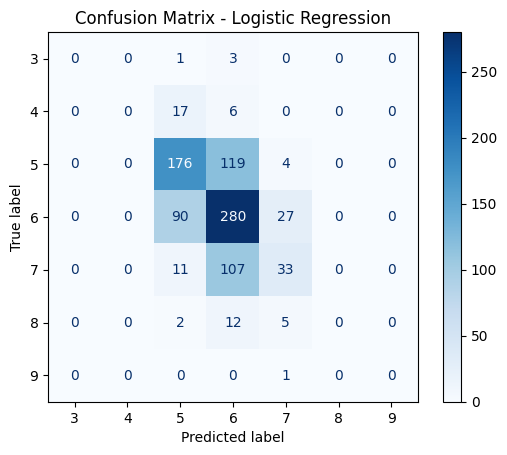


📈 Evaluating Linear SVM...
Accuracy: 0.5391
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.60      0.58      0.59       299
           6       0.51      0.78      0.62       397
           7       0.00      0.00      0.00       151
           8       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         1

    accuracy                           0.54       894
   macro avg       0.16      0.19      0.17       894
weighted avg       0.43      0.54      0.47       894



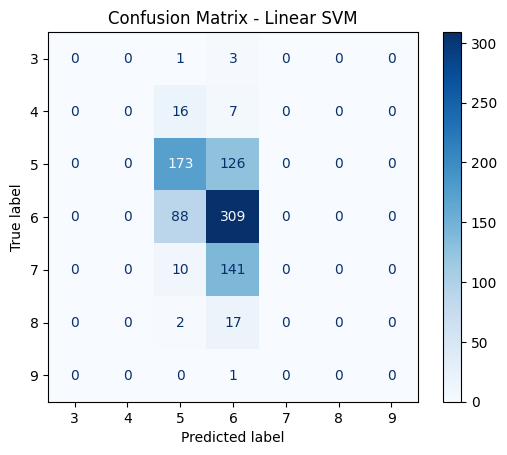


📈 Evaluating Random Forest...
Accuracy: 0.6186
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.04      0.08        23
           5       0.66      0.70      0.68       299
           6       0.61      0.71      0.66       397
           7       0.54      0.40      0.46       151
           8       1.00      0.05      0.10        19
           9       0.00      0.00      0.00         1

    accuracy                           0.62       894
   macro avg       0.47      0.27      0.28       894
weighted avg       0.62      0.62      0.60       894



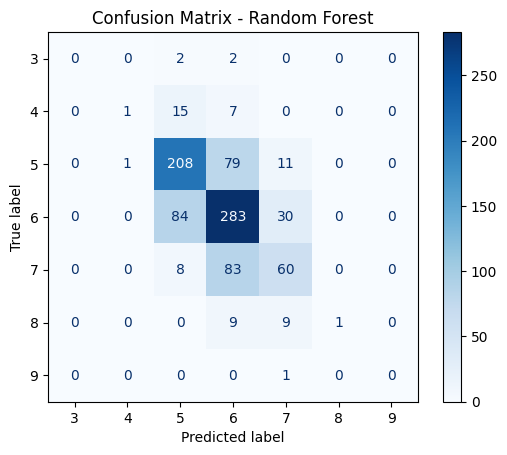


📈 Evaluating KNN (k=15)...
Accuracy: 0.5537
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.60      0.61      0.61       299
           6       0.54      0.64      0.59       397
           7       0.48      0.37      0.42       151
           8       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         1

    accuracy                           0.55       894
   macro avg       0.23      0.23      0.23       894
weighted avg       0.52      0.55      0.54       894



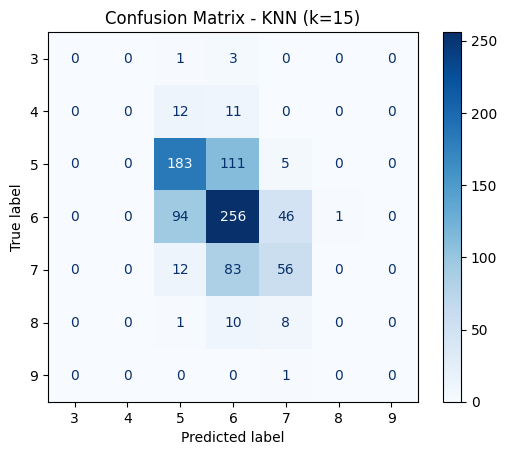


📈 Evaluating KNN (k=30)...
Accuracy: 0.5794
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.63      0.62      0.63       299
           6       0.56      0.72      0.63       397
           7       0.53      0.30      0.39       151
           8       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         1

    accuracy                           0.58       894
   macro avg       0.25      0.24      0.23       894
weighted avg       0.55      0.58      0.55       894



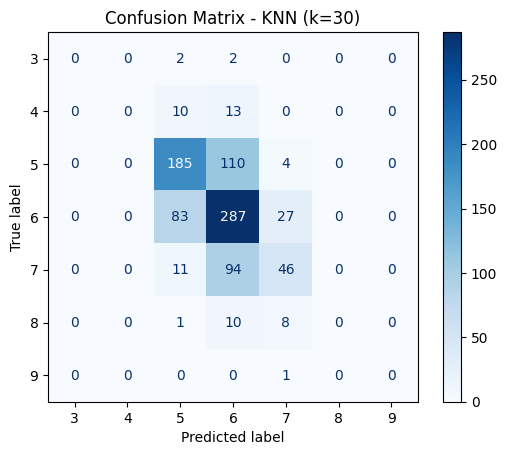


📈 Evaluating Gaussian Naive Bayes...
Accuracy: 0.4966
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.53      0.70      0.60       299
           6       0.57      0.40      0.47       397
           7       0.38      0.49      0.43       151
           8       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         1

    accuracy                           0.50       894
   macro avg       0.21      0.23      0.21       894
weighted avg       0.49      0.50      0.48       894



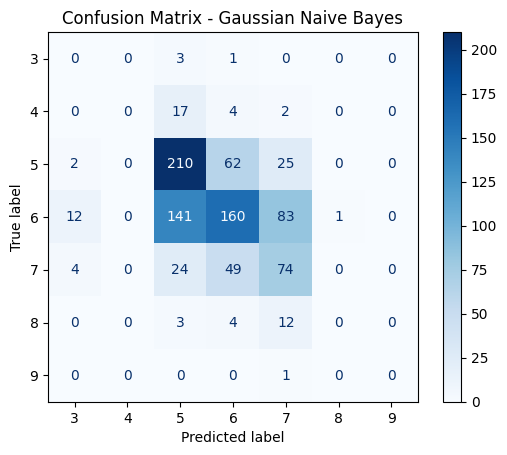


📈 Evaluating Complement Naive Bayes...
Accuracy: 0.4329
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.49      0.74      0.59       299
           6       0.58      0.15      0.23       397
           7       0.32      0.71      0.44       151
           8       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         1

    accuracy                           0.43       894
   macro avg       0.20      0.23      0.18       894
weighted avg       0.47      0.43      0.37       894



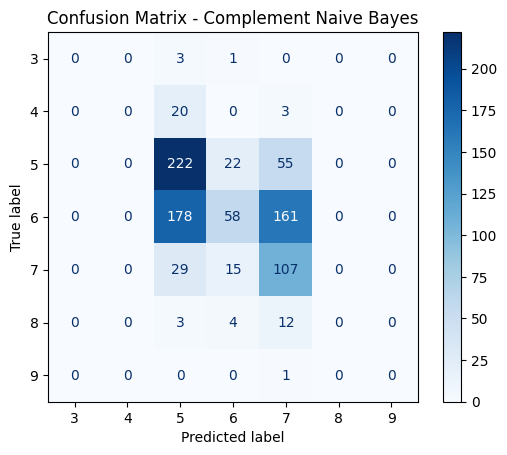


📈 Evaluating Polynomial Regression (deg=3)...
Accuracy: 0.5324
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.60      0.55      0.57       299
           6       0.53      0.66      0.59       397
           7       0.42      0.32      0.37       151
           8       0.20      0.05      0.08        19
           9       0.00      0.00      0.00         1

    accuracy                           0.53       894
   macro avg       0.25      0.23      0.23       894
weighted avg       0.51      0.53      0.52       894



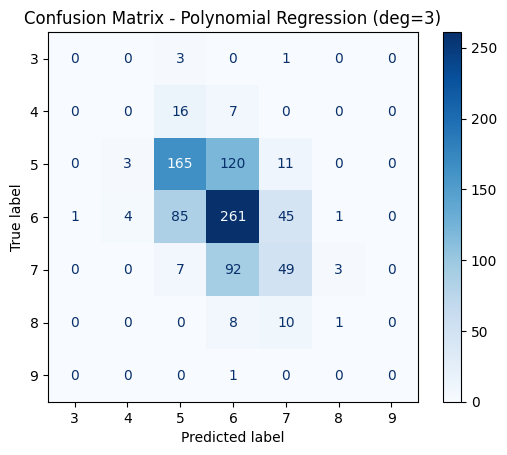


📈 Evaluating Gradient Boosting (experimental)...
Accuracy: 0.6163
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.65      0.67      0.66       299
           6       0.61      0.70      0.65       397
           7       0.55      0.46      0.50       151
           8       0.67      0.11      0.18        19
           9       0.00      0.00      0.00         1

    accuracy                           0.62       894
   macro avg       0.35      0.28      0.29       894
weighted avg       0.60      0.62      0.60       894



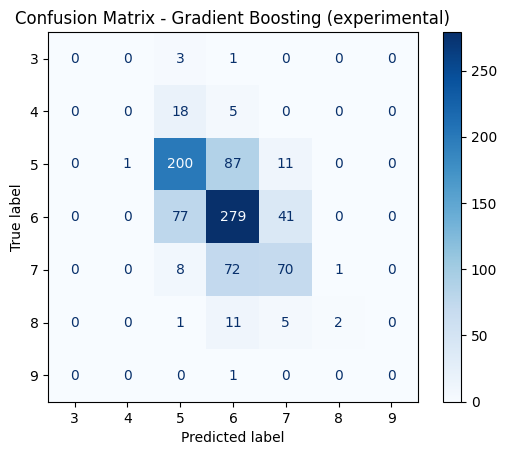


🏆 Model Performance Summary:
                              Model  Accuracy
2                     Random Forest  0.618568
8  Gradient Boosting (experimental)  0.616331
4                        KNN (k=30)  0.579418
3                        KNN (k=15)  0.553691
0               Logistic Regression  0.546980
1                        Linear SVM  0.539150
7     Polynomial Regression (deg=3)  0.532438
5              Gaussian Naive Bayes  0.496644
6            Complement Naive Bayes  0.432886


In [21]:
# ===============================================================
# 📊 MODEL EVALUATION (Fixed + Safe for Regression Outputs)
# ===============================================================
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results = []

for name, model in trained_models.items():
    print(f"\n📈 Evaluating {name}...")

    if isinstance(model, ParzenWindowClassifier):
        y_pred = model.predict(X_val.values)
    elif "Polynomial Regression" in name:
        y_pred = np.round(model.predict(X_val)).astype(int)
        y_pred = np.clip(y_pred, y_val.min(), y_val.max())  # keep in valid range
    else:
        y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    results.append((name, acc))
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_val, y_pred, zero_division=0))

    # --- Fixed Confusion Matrix Display ---
    labels = np.unique(np.concatenate([y_val, y_pred]))
    ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred, labels=labels),
                           display_labels=labels).plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# Summary
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)
print("\n🏆 Model Performance Summary:")
print(results_df)



In [22]:
# ===============================================================
# ⚡ Logistic Regression (Yeo-Johnson + StandardScaler + PolyFeatures)
# ===============================================================
from sklearn.preprocessing import PowerTransformer, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

# ---------------------------------------------------------------
# Define the pipeline
# ---------------------------------------------------------------
optimized_logreg = Pipeline([
    ("power", PowerTransformer(method='yeo-johnson')),  # handles skewed numeric features
    ("scaler", StandardScaler()),                       # standardize mean=0, std=1
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),  # add feature interactions
    ("clf", LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        C=0.02,  
        max_iter=1000,                                      # regularization strength
        random_state=42           # more iterations for convergence
    ))
])

# ---------------------------------------------------------------
# Fit + Predict on validation data
# ---------------------------------------------------------------
optimized_logreg.fit(X_train, y_train)
y_pred = optimized_logreg.predict(X_val)

# ---------------------------------------------------------------
# Evaluate performance
# ---------------------------------------------------------------
print("📈 Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_pred, zero_division=0))

# ===============================================================
# 🏆 Kaggle Submission File (for Logistic Regression)
# ===============================================================
print("\n🚀 Generating Kaggle submission file for Logistic Regression...")

# Ensure your df_test is properly formatted and aligned
print("🔍 Test data shape before prediction:", df_test.shape)

# Generate predictions
test_predictions = optimized_logreg.predict(df_test)

# If your test set uses an 'id' index, use that for the submission
submission = pd.DataFrame({
    "id": df_test.index,
    "quality": test_predictions
})

# Quick sanity check
print("\n✅ Submission preview:")
print(submission.head())
print("Unique predicted values:", np.unique(submission["quality"]))

# Save the file
output_filename = "submission_logistic_regression.csv"
submission.to_csv(output_filename, index=False)
print(f"\n💾 File saved as: {output_filename}")






C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


📈 Accuracy: 0.5738255033557047

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.62      0.64      0.63       299
           6       0.57      0.71      0.63       397
           7       0.48      0.26      0.34       151
           8       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         1

    accuracy                           0.57       894
   macro avg       0.24      0.23      0.23       894
weighted avg       0.54      0.57      0.55       894


🚀 Generating Kaggle submission file for Logistic Regression...
🔍 Test data shape before prediction: (511, 13)

✅ Submission preview:
   id  quality
0   0        6
1   1        6
2   2        7
3   3        8
4   4        6
Unique predicted values: [3 4 5 6 7 8]

💾 File saved as: submission_logistic_regression.csv


## Generate Predictions for Kaggle Submission

Create a CSV file with columns: `id` and `quality` (see README.md for format details).

In [23]:
# ===============================================================
# 🏆 AUTO-GENERATE KAGGLE SUBMISSION (Best Model Automatically Selected)
# ===============================================================
import pandas as pd
import numpy as np

# 1️⃣ Load the Kaggle sample submission template
submission = pd.read_csv("data/sample_submission.csv")
print("📄 Sample submission loaded:")
print(submission.head())

# 2️⃣ Automatically select best model from results_df
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"\n🏆 Best model selected automatically: {best_model_name}")

# 3️⃣ Check test data format
print("🔍 Test data shape before prediction:", df_test.shape)

# 4️⃣ Generate predictions
# (Since models are trained as pipelines, they handle preprocessing automatically)
test_predictions = best_model.predict(df_test)

# 5️⃣ Prepare submission DataFrame
submission["quality"] = test_predictions

# 6️⃣ Sanity checks
print("\n✅ Submission preview:")
print(submission.head())
print("\nUnique predicted quality values:", np.unique(submission["quality"]))
print("Submission shape:", submission.shape)

# 7️⃣ Save final submission file
output_filename = f"submission_{best_model_name.replace(' ', '_').lower()}.csv"
submission.to_csv(output_filename, index=False)
print(f"\n💾 Kaggle submission file saved as: {output_filename}")




📄 Sample submission loaded:
   id  quality
0   0        7
1   1        4
2   2        6
3   3        5
4   4        6

🏆 Best model selected automatically: Random Forest
🔍 Test data shape before prediction: (511, 13)

✅ Submission preview:
   id  quality
0   0        6
1   1        5
2   2        7
3   3        7
4   4        6

Unique predicted quality values: [4 5 6 7 8]
Submission shape: (511, 2)

💾 Kaggle submission file saved as: submission_random_forest.csv


---
Good luck with the competition! 🍺
